# Prática — Módulo 11: Perceptrons

In [22]:
# Importações
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron

# Parte 01 - AND

In [23]:
# Base AND
# Entradas
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Saídas esperadas
y = np.array([0, 0, 0, 1])

print(X)
print(y)

[[0 0]
 [0 1]
 [1 0]
 [1 1]]
[0 0 0 1]


In [24]:
# Treinamento do perceptron
modelo = Perceptron()

modelo.fit(X, y)

print("Pesos:", modelo.coef_)
print("Bias:", modelo.intercept_)

Pesos: [[2. 2.]]
Bias: [-2.]


In [25]:
# Previsões
predicoes = modelo.predict(X)

print("Previsões:")
print(predicoes)

Previsões:
[0 0 0 1]


In [26]:
# Comparação
for entrada, esperado, previsto in zip(X, y, predicoes):
    print(f"Entrada: {entrada} | Esperado: {esperado} | Previsto: {previsto}")

Entrada: [0 0] | Esperado: 0 | Previsto: 0
Entrada: [0 1] | Esperado: 0 | Previsto: 0
Entrada: [1 0] | Esperado: 0 | Previsto: 0
Entrada: [1 1] | Esperado: 1 | Previsto: 1


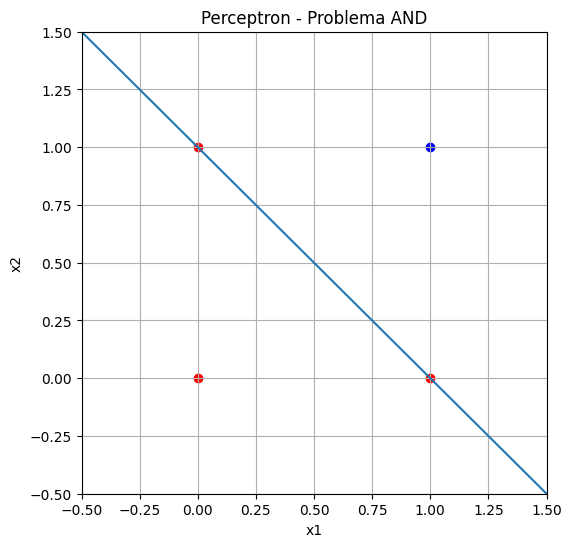

In [27]:
# Visualização da fronteira
plt.figure(figsize=(6,6))

# Plotar pontos
for i in range(len(X)):
    if y[i] == 0:
        plt.scatter(X[i][0], X[i][1], color='red')
    else:
        plt.scatter(X[i][0], X[i][1], color='blue')

# Fronteira de decisão
w = modelo.coef_[0]
b = modelo.intercept_[0]

x_vals = np.array([-0.5, 1.5])

y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Perceptron - Problema AND")

plt.grid(True)

plt.show()

# Parte 02 - XOR

In [28]:
# Base XOR
# Entradas
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Saídas XOR
y_xor = np.array([0, 1, 1, 0])

print(X_xor)
print(y_xor)

[[0 0]
 [0 1]
 [1 0]
 [1 1]]
[0 1 1 0]


In [29]:
# Treinamento do perceptron
modelo_xor = Perceptron(max_iter=1000)

modelo_xor.fit(X_xor, y_xor)

print("Pesos:", modelo_xor.coef_)
print("Bias:", modelo_xor.intercept_)

Pesos: [[0. 0.]]
Bias: [0.]


In [30]:
# Previsões
predicoes_xor = modelo_xor.predict(X_xor)

print("Previsões:")
print(predicoes_xor)

Previsões:
[0 0 0 0]


In [31]:
# Comparação
for entrada, esperado, previsto in zip(X_xor, y_xor, predicoes_xor):
    print(f"Entrada: {entrada} | Esperado: {esperado} | Previsto: {previsto}")

Entrada: [0 0] | Esperado: 0 | Previsto: 0
Entrada: [0 1] | Esperado: 1 | Previsto: 0
Entrada: [1 0] | Esperado: 1 | Previsto: 0
Entrada: [1 1] | Esperado: 0 | Previsto: 0


In [32]:
# Acurácia
acuracia = np.mean(predicoes_xor == y_xor)

print("Acurácia:", acuracia)

Acurácia: 0.5


/tmp/ipykernel_13419/654670475.py:15: RuntimeWarning: invalid value encountered in divide
  y_vals = -(w[0] * x_vals + b) / w[1]


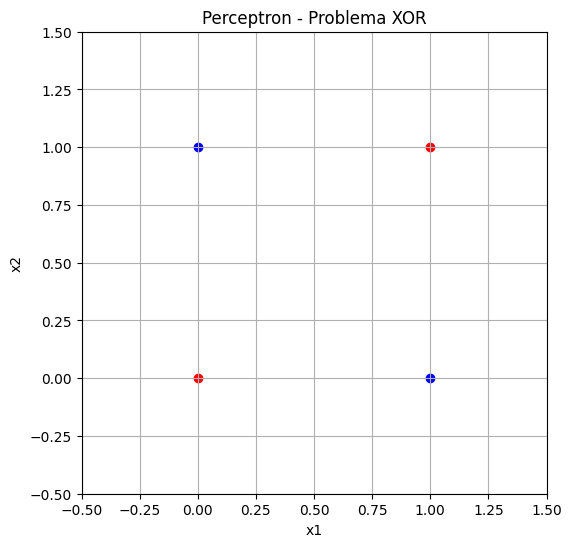

In [33]:
# Visualização
plt.figure(figsize=(6,6))

for i in range(len(X_xor)):
    if y_xor[i] == 0:
        plt.scatter(X_xor[i][0], X_xor[i][1], color='red')
    else:
        plt.scatter(X_xor[i][0], X_xor[i][1], color='blue')

w = modelo_xor.coef_[0]
b = modelo_xor.intercept_[0]

x_vals = np.array([-0.5, 1.5])

y_vals = -(w[0] * x_vals + b) / w[1]

plt.plot(x_vals, y_vals)

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Perceptron - Problema XOR")

plt.grid(True)

plt.show()

# Problema Linearmente Simples

In [34]:
# Base linearmente separável

dados = {
    "renda": [
        0.22, 0.28, 0.35, 0.31, 0.40,
        0.45, 0.52, 0.60, 0.55, 0.48,
        0.62, 0.70, 0.78, 0.85, 0.90,
        0.58, 0.66, 0.73, 0.81, 0.95
    ],

    "score": [
        0.30, 0.42, 0.38, 0.50, 0.45,
        0.52, 0.60, 0.72, 0.66, 0.58,
        0.70, 0.75, 0.82, 0.88, 0.91,
        0.62, 0.77, 0.80, 0.86, 0.95
    ],

    "idade": [
        0.65, 0.55, 0.48, 0.72, 0.60,
        0.40, 0.35, 0.30, 0.45, 0.50,
        0.28, 0.33, 0.38, 0.42, 0.47,
        0.58, 0.36, 0.41, 0.44, 0.39
    ],

    "aprovado": [
        0, 0, 0, 0, 0,
        0, 1, 1, 1, 0,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(dados)

df

,renda,score,idade,aprovado
0,0.22,0.30,0.65,0
1,0.28,0.42,0.55,0
2,0.35,0.38,0.48,0
3,0.31,0.50,0.72,0
4,0.40,0.45,0.60,0
5,0.45,0.52,0.40,0
6,0.52,0.60,0.35,1
7,0.60,0.72,0.30,1
8,0.55,0.66,0.45,1
9,0.48,0.58,0.50,0


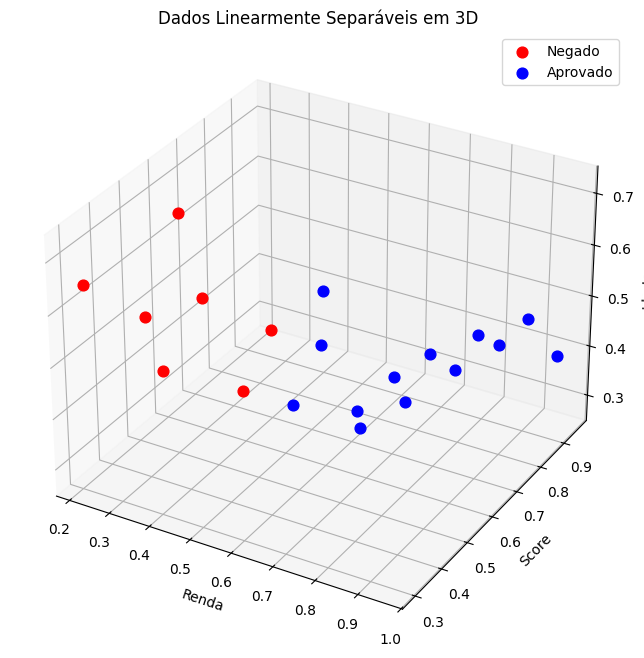

In [35]:
fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')

for i in range(len(df)):

    if df["aprovado"][i] == 0:
        ax.scatter(
            df["renda"][i],
            df["score"][i],
            df["idade"][i],
            color='red',
            s=60,
            label='Negado' if i == 0 else ""
        )

    else:
        ax.scatter(
            df["renda"][i],
            df["score"][i],
            df["idade"][i],
            color='blue',
            s=60,
            label='Aprovado' if i == 6 else ""
        )

ax.set_xlabel("Renda")
ax.set_ylabel("Score")
ax.set_zlabel("Idade")

ax.set_title("Dados Linearmente Separáveis em 3D")

ax.legend()

plt.show()

In [36]:
# Separar X e y
X = df[["renda", "score", "idade"]]

y = df["aprovado"]

print(X.head())

print(y.head())

   renda  score  idade
0   0.22   0.30   0.65
1   0.28   0.42   0.55
2   0.35   0.38   0.48
3   0.31   0.50   0.72
4   0.40   0.45   0.60
0    0
1    0
2    0
3    0
4    0
Name: aprovado, dtype: int64


In [37]:
# Treinar perceptron
modelo = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

modelo.fit(X, y)

Perceptron(eta0=0.1, random_state=42)

In [38]:
# Pesos aprendidos

print("Pesos aprendidos:")

print(modelo.coef_)

print("\nBias:")

print(modelo.intercept_)

Pesos aprendidos:
[[ 0.168  0.123 -0.125]]

Bias:
[-0.1]


In [39]:
# Previsões
predicoes = modelo.predict(X)

print(predicoes)

[0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1]


In [40]:
# Comparação
resultado = df.copy()

resultado["previsto"] = predicoes

resultado

,renda,score,idade,aprovado,previsto
0,0.22,0.30,0.65,0,0
1,0.28,0.42,0.55,0,0
2,0.35,0.38,0.48,0,0
3,0.31,0.50,0.72,0,0
4,0.40,0.45,0.60,0,0
5,0.45,0.52,0.40,0,0
6,0.52,0.60,0.35,1,1
7,0.60,0.72,0.30,1,1
8,0.55,0.66,0.45,1,1
9,0.48,0.58,0.50,0,0


In [41]:
# Acurácia
acuracia = accuracy_score(y, predicoes)

print(f"Acurácia: {acuracia:.2f}")

Acurácia: 1.00


In [42]:
# Interpretação
print("Equação linear aprendida pelo perceptron:\n")

P1 = modelo.coef_[0][0]
P2 = modelo.coef_[0][1]
P3 = modelo.coef_[0][2]

Bias = modelo.intercept_[0]

print(f"z = ({P1:.3f} * renda) + ({P2:.3f} * score) + ({P3:.3f} * idade) + ({b:.3f})")

Equação linear aprendida pelo perceptron:

z = (0.168 * renda) + (0.123 * score) + (-0.125 * idade) + (0.000)
